In [1]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

BASE = pathlib.Path(".")  # notebook lives in code/realistic/

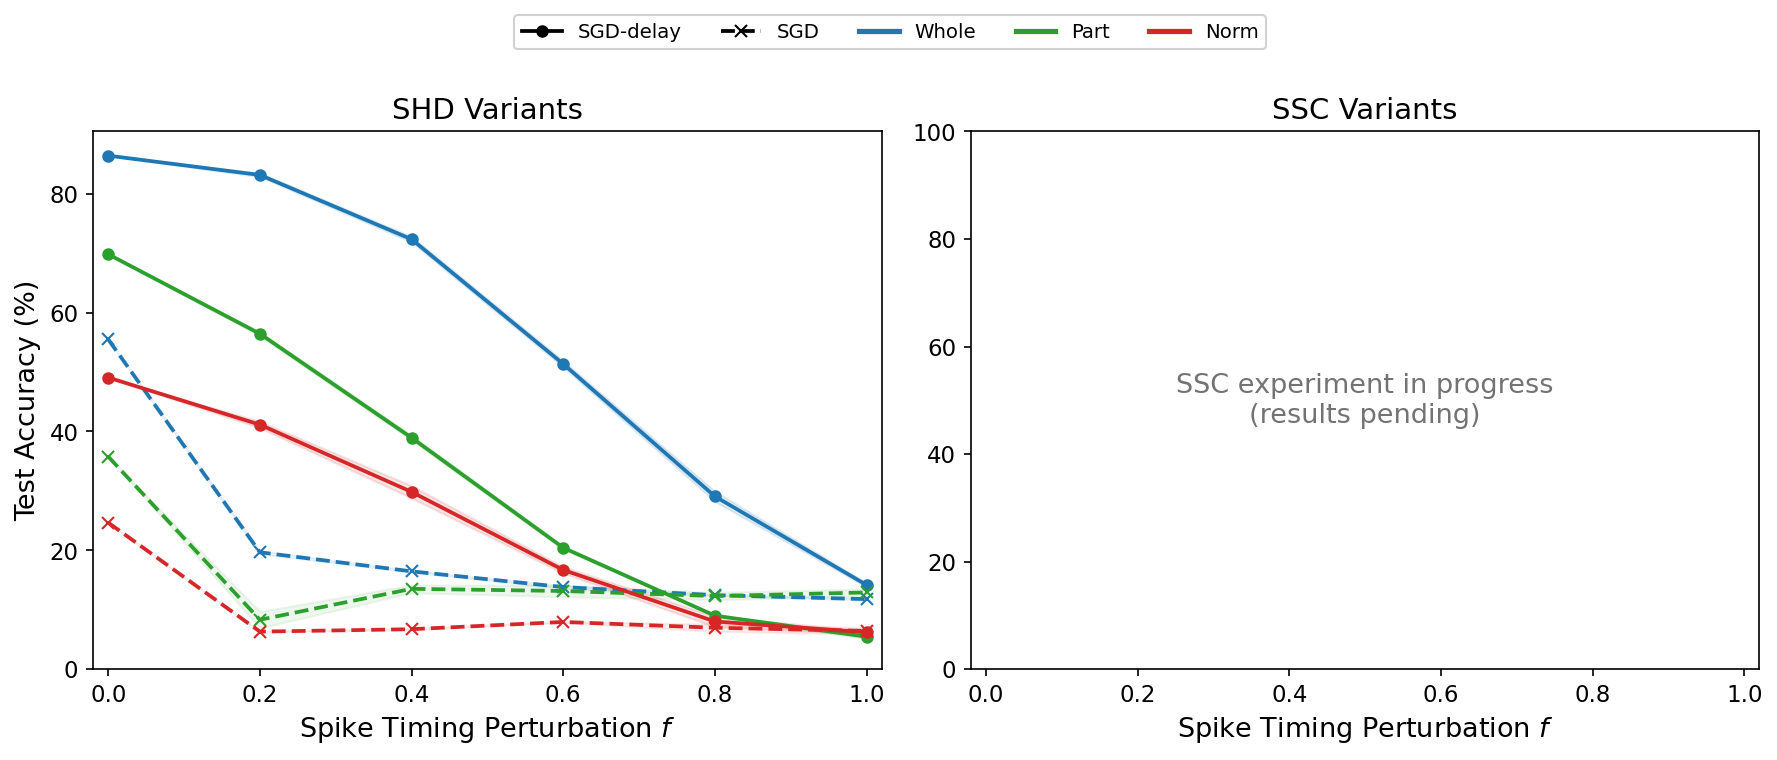

In [2]:
def load_results(path: pathlib.Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load a perturbation results JSON file.

    Args:
        path: Path to a ``*_perturbation_results.json`` file mapping each
            perturbation level to a dict with ``mean`` and ``std`` entries.

    Returns:
        A tuple ``(f_values, means, stds)`` where accuracies are in percent.
    """
    with open(path) as fh:
        raw = json.load(fh)
    keys = sorted(raw, key=float)
    f_values = np.array([float(key) for key in keys])
    means = np.array([raw[key]["mean"] for key in keys]) * 100
    stds = np.array([raw[key]["std"] for key in keys]) * 100
    return f_values, means, stds


def results_path(dataset: str, variant: str, delay_mode: str) -> pathlib.Path:
    """Build the results file path for one dataset/variant/delay combination."""
    filename = f"{dataset}_{variant}_{delay_mode}_input_perturbation_results.json"
    return BASE / dataset / "log" / filename


def load_dataset(dataset: str, variants: list[str]) -> dict[tuple[str, str], tuple]:
    """Load every available results file for one dataset.

    Missing files are skipped, so a partially finished experiment still plots.
    """
    loaded = {}
    for variant in variants:
        for delay_mode in DELAY_MODES:
            path = results_path(dataset, variant, delay_mode)
            if path.exists():
                loaded[(variant, delay_mode)] = load_results(path)
    return loaded


# ---------- Plot configuration ----------
COLORS = {"whole": "#1f77b4", "part": "#2ca02c", "norm": "#d62728"}  # blue, green, red
LABELS = {"whole": "Whole", "part": "Part", "norm": "Norm"}
DELAY_MODES = ["delay", "nodelay"]
STYLES = {
    "delay": {"fmt": "o-", "markersize": 5, "band_alpha": 0.12},
    "nodelay": {"fmt": "x--", "markersize": 6, "band_alpha": 0.08},
}

SHD_VARIANTS = ["whole", "part", "norm"]
SSC_VARIANTS = ["part", "norm"]

shd_results = load_dataset("shd", SHD_VARIANTS)
ssc_results = load_dataset("ssc", SSC_VARIANTS)


def plot_panel(ax: plt.Axes, results: dict[tuple[str, str], tuple]) -> None:
    """Draw all mean curves with +/- 1 std bands onto one axis."""
    for (variant, delay_mode), (f_values, means, stds) in results.items():
        style = STYLES[delay_mode]
        ax.plot(
            f_values,
            means,
            style["fmt"],
            color=COLORS[variant],
            markersize=style["markersize"],
            linewidth=1.8,
        )
        ax.fill_between(
            f_values,
            means - stds,
            means + stds,
            color=COLORS[variant],
            alpha=style["band_alpha"],
        )


fig, (ax_shd, ax_ssc) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# ==================== SHD panel ====================
plot_panel(ax_shd, shd_results)
ax_shd.set_title("SHD Variants")
ax_shd.set_xlabel("Spike Timing Perturbation $f$")
ax_shd.set_ylabel("Test Accuracy (%)")
ax_shd.set_xlim(-0.02, 1.02)
ax_shd.set_ylim(0, None)

# ==================== SSC panel ====================
# The SSC experiment is still running; show a placeholder until its logs exist.
if ssc_results:
    plot_panel(ax_ssc, ssc_results)
    ax_ssc.set_ylim(0, None)
else:
    ax_ssc.text(
        0.5,
        0.5,
        "SSC experiment in progress\n(results pending)",
        transform=ax_ssc.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        color="0.45",
    )
    ax_ssc.set_ylim(0, 100)

ax_ssc.set_title("SSC Variants")
ax_ssc.set_xlabel("Spike Timing Perturbation $f$")
ax_ssc.set_xlim(-0.02, 1.02)

# ==================== Shared legend ====================
plotted_variants = {variant for variant, _ in shd_results} | {variant for variant, _ in ssc_results}

handles = [
    mlines.Line2D([], [], color="black", marker="o", linestyle="-", markersize=5, linewidth=1.8, label="SGD-delay"),
    mlines.Line2D([], [], color="black", marker="x", linestyle="--", markersize=6, linewidth=1.8, label="SGD"),
]
handles += [
    mlines.Line2D([], [], color=COLORS[variant], linewidth=2.5, label=LABELS[variant])
    for variant in SHD_VARIANTS
    if variant in plotted_variants
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=len(handles),
    framealpha=0.9,
    bbox_to_anchor=(0.5, 1.02),
)

fig.tight_layout(rect=[0, 0, 1, 0.93])
# plt.savefig("shd_ssc_hidden_perturbation.png", dpi=300, bbox_inches="tight")
plt.show()